<h1> ML модель для выявления рисков при доставке</h1>

<h1>ML модель для выявления рисков при доставке</h1>

<h3>Цель:</h3>
<p>
Создать модель для выявления риска по недостатку времени при доставке для поиска путей оптимизации и минимизации затрат
</p>

<h3>Задача:</h3>
<p>
Построить ML модель классификации, которая по профилю заказчика выявляет вероятность неудачной доставки, чтобы минимизировать финансовые потери
</p>

<h3>План работы</h3>
<ul>
    <li>Этап 1: Загрузка данных и знакомство с ними</li>
    <li>Этап 2: EDA</li>
    <li>Этап 3: Создание выборок (GroupShuffleSplit)</li>
    <li>Этап 4: Обучение базовой модели</li>
    <li>Этап 5: Кластеризация по географическим признакам</li>
    <li>Этап 6: Кластеризация по профилям клиентов</li>
    <li>Этап 7: Обучение модели на новых признаках</li>
    <li>Этап 8: Тестирование лучшей модели</li>
    <li>Этап 9: Выводы и рекомендации для бизнеса</li>
</ul>

<h3>Перевод бизнес-задачи на язык машинного обучения</h3>
<p>
Бизнес задача: выявления риска по недостатку времени при доставке для поиска путей оптимизации и минимизации затрат
Это задача бинарной классификации со значением 1 - времени на доставку не хватило, 0 - хватило времени на доставку.
</p>
<p>
Для решения задачи будут использованы модель градиентного бустинга CatBoost и логистической регрессии в качестве базовых моделей для проверки какая лучше всего описывает данные
С помощью KMeans++ будет проведена кластеризация объектов, для проверки гипотезы улучшения качества модели при кластеризации  
</p>
<p>Технические метрики</p>
<ul>
    <li>ROC-AUC - способность модели различать положительный и отрицательный классы независимо от выбранного порога классификации</li>
    <li>AUC-PR - площадь под кривой Precision-Recall. Чем ближе значение к 1, тем лучше модель разделяет классы на возможных порогах информативна на несбалансированных данных </li>
    <li>Precision - доля объектов, предсказанных моделью как положительный класс, которые действительно относятся к положительному классу</li>
    <li>Recall - доля объектов положительного класса, которые модель смогла найти</li>

<h2>Этап 1 Подготовка среды: загрузка данных, фиксация random_state, установка библиотек</h2>

In [1]:
import numpy as np
import pandas as pd
import phik
import optuna
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (GroupShuffleSplit, cross_validate, cross_val_predict, cross_val_score, StratifiedKFold)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
import catboost as cb
from catboost import CatBoostClassifier
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE


from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score, recall_score, f1_score, precision_recall_curve, roc_curve,
                             average_precision_score, confusion_matrix, ConfusionMatrixDisplay, classification_report, make_scorer)


import shap

<h3>Зафиксируем <code>random_state</code> и параметры отображения</h3>

In [2]:
plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

RANDOM_STATE = 42

<ul>
    <li><code>plt.style.use('default')</code> - использование стандартного стиля визуализации matplotlib.</li>
    <li><code>plt.rcParams['figure.figsize'] = (10, 6)</code> - размер графиков.</li>
    <li><code>plt.rcParams['font.size'] = 12</code> - размер шрифта на графиках.</li>
    <li><code>RANDOM_STATE = 42</code> - фиксация генератора случайных чисел для воспроизводимости результатов.</li>
</ul>

<h3>Загрузим данные из CSV-файлов:</h3>
<ul>
    <li>ds_s18_customers.csv</li>
    <li>ds_s18_orders.csv</li>
</ul>

In [3]:
try:
    customers = pd.read_csv('ds_s18_customers.csv')
    orders = pd.read_csv('ds_s18_orders.csv')
except:
    customers = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s18_customers.csv')
    orders = pd.read_csv('https://code.s3.yandex.net/datasets/ds_s18_orders.csv')

In [4]:
datasets = {'customers': customers,
            'orders': orders,}

for name, df in datasets.items():
    print(f'{name}: {df.shape}')

customers: (20652, 8)
orders: (180519, 7)


<p><b>Среда разработки поготовлена, данные выгружены. Переходим к EDA </b></p>

<h2>Этап 2: EDA</h2>

In [5]:
def datasets_info(datasets):
    for name, df in datasets.items():
        print(name)
        
        for col in df.columns:
            print(f"\t{col}"
                  f"\n\t\tтип: {df[col].dtype}"
                  f"\n\t\tвсего строк: {len(df[col])}"
                  f"\n\t\tпропусков: {df[col].isna().sum()}"
                  f"\n\t\tуникальных значений: {len(list(df[col].dropna().unique()))}"
                  f"\n\t\tпримеры возможных значений: {list(df[col].dropna().unique()[:5])}")
        print()
datasets_info(datasets)

customers
	customer_id
		тип: int64
		всего строк: 20652
		пропусков: 0
		уникальных значений: 20652
		примеры возможных значений: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
	customer_lat
		тип: float64
		всего строк: 20652
		пропусков: 0
		уникальных значений: 12769
		примеры возможных значений: [np.float64(25.95364761), np.float64(38.37559509), np.float64(18.025375370000003), np.float64(33.67002106), np.float64(18.35910416)]
	customer_lon
		тип: float64
		всего строк: 20652
		пропусков: 0
		уникальных значений: 6161
		примеры возможных значений: [np.float64(-97.5076828), np.float64(-104.7260208), np.float64(-66.61508178999999), np.float64(-112.2470779), np.float64(-66.07791138)]
	total_sales
		тип: float64
		всего строк: 20652
		пропусков: 0
		уникальных значений: 12632
		примеры возможных значений: [np.float64(472.4500122), np.float64(1618.6600417900004), np.float64(3189.2000370200003), np.float64(1480.70999322), np.float64(1101.91999814)]
	total_orders
		тип:

<h4>Вывод по первичному анализу</h4>
<ul>
    <li>customers всего строк 20652
        <ul>
            <li><code>customer_id</code> количество строк совпадает с количеством уникальным значений все идентифекаторы уникальны</li>
            <li><code>customer_lat</code> <code>customer_lon</code> признаки на месторасположения, в совокупности даю удаленность клиента можно использовать для подсчета евклидово расстояния, следует провести проверку на нестандартные значения с точки зрения географии</li>
            <li><code>total_sales</code>
                <code>total_orders</code>
                <code>recency</code> основные признаки для составления портрета пользователя следует сделать проверку на выбросы и проанализировать распределение</li>
            <li><code>return_rate</code>
                <code>avg_discount</code> признаки помогающие дополнить профиль пользователя так же как и с основными  следует сделать проверку на выбросы и проанализировать распределение</li>
            <li>Явных пропусков и возможных дубликатов id нет, следует сделать проверку на невалидные значения и возможные значения заглушки для пропусков</li>
        </ul>
    </li>   
    <li>orders всего строк 180519
        <ul>
            <li><code>order_id</code> количество строк совпадает с количеством уникальным значений все идентифекаторы уникальны</li>
            <li><code>customer_id</code> количество уникальных значений совпадает с количеством в <code>customers</code> следует явно проверить что идентификаторы в обоих таблицах одинаковы</li>
            <li><code>late_delivery_risk</code> целевая переменная созначениями 1 и 0 аномалий нет следует проверить дисбаланс</li>
            <li><code>shipping_mode</code> значение соответствуют заявленным следует рассмотреть распределение целевой переменной в зависимоти от режима доставки</li>
            <li><code>category_name</code> ассортимент велик 50 разных категорий следует рассмотреть есть ли аномальное количество неудач в одной из них</li>
            <li><code>order_date</code> хранит дату и время доставки необходима перетипизация и разбиение по отдельным переменным месяц год время
            после можно рассмотреть менялось ли количество неудачных доставок с изменением даты, а так же рассмотреть пики заказов по времени</li>
            <li><code>item_price</code> можно рассмотреть вероятность неудачи в зависимости от цены товара, так как у нас нет признака габарита, мы можем лтшь догадываться что он зависит от стоимости</li>
        </ul>
    </li>
</ul>

<h3>Проверка на дубликаты</h3>

In [6]:
id_cols = ['customer_id', 'order_id'] 
def duplicates_report(df, id_cols=[]):
    full_dup = df.duplicated().sum()
    print("Полные дубликаты строк:", full_dup)
    
    if id_cols:
        for id_col in id_cols:
            if id_col in df.columns:
                id_dup = df.duplicated(subset=[id_col]).sum()
                print(f"Дубликаты по {id_col}: {id_dup}")
                no_id = df.drop(columns=[id_col])
                no_id_dup = no_id.duplicated().sum()
                print(f"Дубликаты без {id_col}: {no_id_dup}")

for name, df in datasets.items():
    print(name)
    duplicates_report(df, id_cols)
    print("\n")

customers
Полные дубликаты строк: 0
Дубликаты по customer_id: 0
Дубликаты без customer_id: 5


orders
Полные дубликаты строк: 0
Дубликаты по customer_id: 159867
Дубликаты без customer_id: 0
Дубликаты по order_id: 0
Дубликаты без order_id: 20806




Дубликаты в orders без order_id: 20806: один клиент не может совершить два идентичных заказа в один момент времени
Дубликаты в customers без id: два разных клиента не могут иметь одинаковые координаты, продажи и поведение записей.
Удаляем дубликаты, сохраняя первое вхождение

In [7]:
mask = customers.drop(columns=['customer_id']).duplicated(keep='first')
customers = customers[~mask]
mask = orders.drop(columns=['order_id']).duplicated(keep='first')
orders = orders[~mask]

datasets = {'customers': customers,
            'orders': orders}
for name, df in datasets.items():
    print(name)
    duplicates_report(df, id_cols)
    print("\n")

customers
Полные дубликаты строк: 0
Дубликаты по customer_id: 0
Дубликаты без customer_id: 0


orders
Полные дубликаты строк: 0
Дубликаты по customer_id: 139061
Дубликаты без customer_id: 0
Дубликаты по order_id: 0
Дубликаты без order_id: 0




### Разобьём order_date на временные столбцы `order_month`, `order_weekday`, `order_hour`

In [8]:
orders['order_date'] = pd.to_datetime(orders['order_date'])
orders['order_month'] = orders['order_date'].dt.month
orders['order_weekday'] = orders['order_date'].dt.dayofweek  
orders['order_hour'] = orders['order_date'].dt.hour
orders.head(5)

,order_id,customer_id,late_delivery_risk,shipping_mode,category_name,order_date,item_price,order_month,order_weekday,order_hour
0,180517,20755,0,Standard Class,Sporting Goods,2018-01-31 22:56:00,327.75,1,2,22
1,179254,19492,1,Standard Class,Sporting Goods,2018-01-13 12:27:00,327.75,1,5,12
2,179253,19491,0,Standard Class,Sporting Goods,2018-01-13 12:06:00,327.75,1,5,12
3,179252,19490,0,Standard Class,Sporting Goods,2018-01-13 11:45:00,327.75,1,5,11
4,179251,19489,0,Standard Class,Sporting Goods,2018-01-13 11:24:00,327.75,1,5,11


<h3>Проверим баланс классов</h3>

Количество объектов:
late_delivery_risk
1    87653
0    72060
Name: count, dtype: int64
Доли классов:
late_delivery_risk
1    0.548816
0    0.451184
Name: proportion, dtype: float64


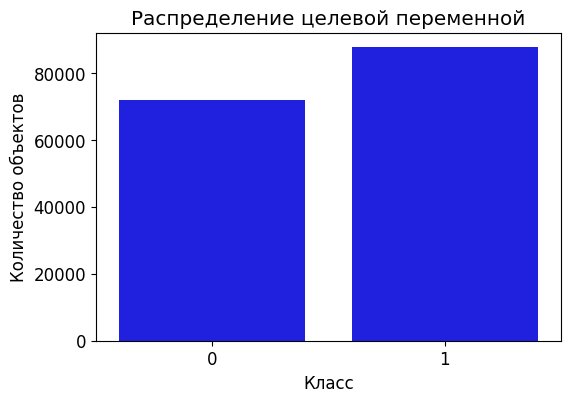

In [9]:
def target_distribution(x):
    value_counts = x.value_counts()
    value_share = x.value_counts(normalize=True)
    print('Количество объектов:')
    print(value_counts)
    print('Доли классов:')
    print(value_share)

    plt.figure(figsize=(6, 4))
    sns.countplot(x=x, color='blue')
    plt.title('Распределение целевой переменной')
    plt.xlabel('Класс')
    plt.ylabel('Количество объектов')
    plt.show()
target_distribution(datasets['orders']['late_delivery_risk'])

Дисбаланс классов минимален

Подтверждено, что около 55% всех заказов доставляются с задержкой 

<h3>Географический аудит</h3>

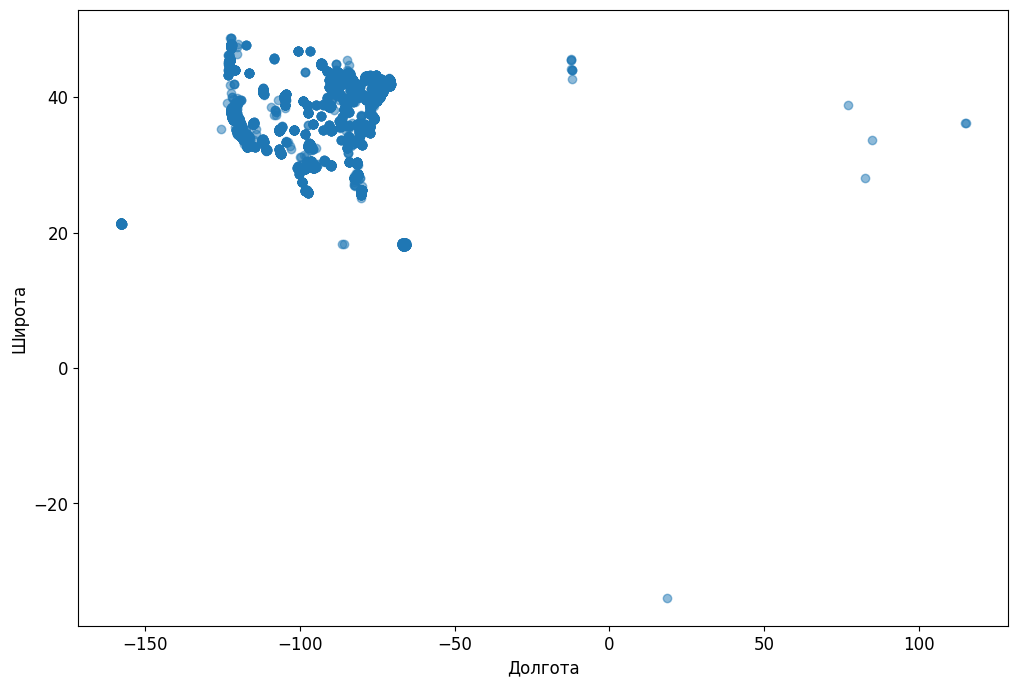

In [10]:
plt.figure(figsize=(12, 8))
plt.scatter(customers['customer_lon'], customers['customer_lat'], alpha=0.5)
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.show()

обнаружены аномальные точки, удаляем согласно заданным условиям по координатам ""<em>значения, выходящие за пределы диапазона долготы –125 до –20</em>""

In [11]:
print("До:")
print("Клиентов:", len(customers))
print("Заказов:", len(orders))

customers = customers[(customers['customer_lon'] >= -125) & (customers['customer_lon'] <= -20)]
orders = orders[orders['customer_id'].isin(customers['customer_id'])]

print("После:")
print("Клиентов:", len(customers))
print("Заказов:", len(orders))

До:
Клиентов: 20647
Заказов: 159713
После:
Клиентов: 20491
Заказов: 158444


<h3>Обработка категориальный значений</h3>

In [12]:
def categorical_analysis(df, cat_cols):
    for col in cat_cols:
        print("Столбец:", col)
        print("Уникальных значений:", df[col].nunique())
        print("Примеры значений:", df[col].unique()[:10])
        print()

cat_cols = ['shipping_mode', 'category_name']

for name, df in datasets.items():
    cols = [col for col in cat_cols if col in df.columns]

    if cols:
        print(name, "\n")
        categorical_analysis(df, cols)
        print("\n")

orders 

Столбец: shipping_mode
Уникальных значений: 4
Примеры значений: <StringArray>
['Standard Class', 'First Class', 'Second Class', 'Same Day']
Length: 4, dtype: str

Столбец: category_name
Уникальных значений: 50
Примеры значений: <StringArray>
[    'Sporting Goods',             'Cleats',      'Shop By Sport',
    'Women's Apparel',        'Electronics',       'Boxing & MMA',
   'Cardio Equipment',           'Trade-In',   'Kids' Golf Clubs',
 'Hunting & Shooting']
Length: 10, dtype: str





странных значений нет ни у одного признака, для кодировки признаков используем 
<ul>
    <li>OHE для <code>shipping_mode</code></li>
    <li>Ordinal Encoding для category_name</li>
</ul>

<h3>Анализ выбросов и распределления</h3>

In [13]:
def data_review(df, col):
    data = df[col].dropna()
    print(data.describe())
    
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outliers = data[(data < lower_bound) | (data > upper_bound)]
    high_outliers = data[data > upper_bound].sort_values(ascending=True)
    low_outliers = data[data < lower_bound].sort_values(ascending=True)
    
    print("Выбросы:")
    print("Количество:", len(outliers))
    print("Процент:", round(len(outliers) / len(data) * 100, 2))
    print("Границы:", round(lower_bound, 2), round(upper_bound, 2))
    print("Первые 5 выбросов выше верхней границы:", high_outliers.head(5).values)
    print("5 максимальных значений:", high_outliers.tail(5).values)
    print("Первые 5 выбросов ниже нижней границы:", low_outliers.tail(5).values)
    print("5 минимальных значений:", low_outliers.head(5).values)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(data, kde=True, ax=axes[0])
    axes[0].set_title(f"Hist: {col}")
    sns.boxplot(x=data, ax=axes[1])
    axes[1].set_title(f"Boxplot: {col}")
    plt.tight_layout()
    plt.show()



 customers 

Столбец:  total_sales 

count    20647.000000
mean      1600.880648
std       1508.441813
min          8.470000
25%        254.940002
50%       1295.219995
75%       2621.685043
max       9436.610088
Name: total_sales, dtype: float64
Выбросы:
Количество: 122
Процент: 0.59
Границы: -3295.18 6171.8
Первые 5 выбросов выше верхней границы: [6188.54007722 6194.66010668 6200.46009836 6206.85003289 6207.5001184 ]
5 максимальных значений: [8198.15006854 8221.64012954 8222.670103   8400.98010666 9436.61008833]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


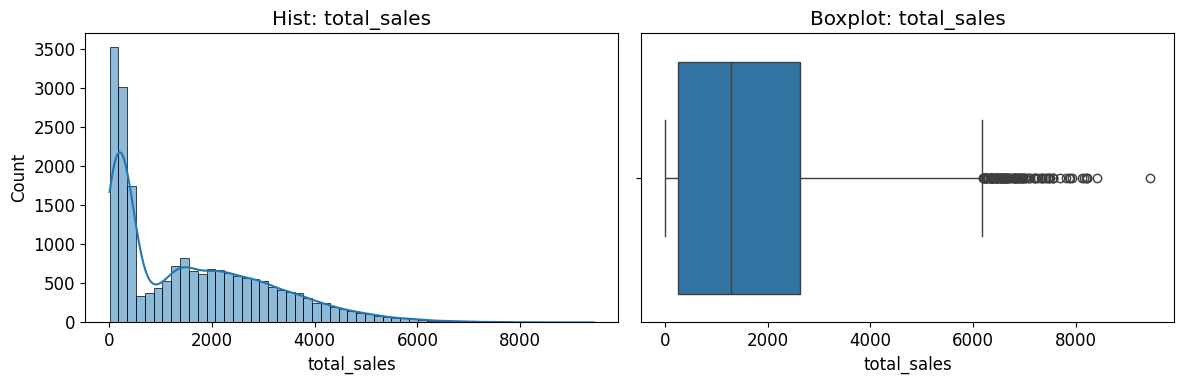

Столбец:  total_orders 

count    20647.000000
mean         3.184337
std          2.430756
min          1.000000
25%          1.000000
50%          3.000000
75%          5.000000
max         15.000000
Name: total_orders, dtype: float64
Выбросы:
Количество: 47
Процент: 0.23
Границы: -5.0 11.0
Первые 5 выбросов выше верхней границы: [12 12 12 12 12]
5 максимальных значений: [14 14 14 14 15]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


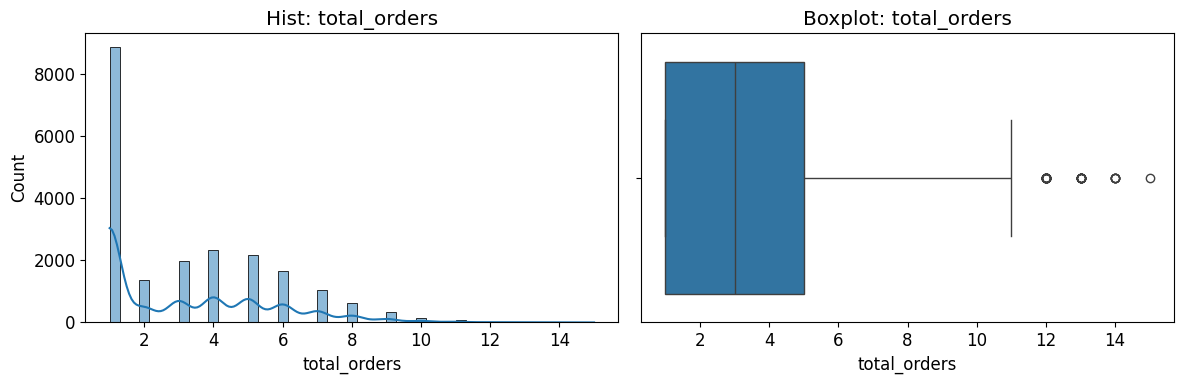

Столбец:  recency 

count    20647.000000
mean       221.129026
std        199.402272
min          1.000000
25%         76.000000
50%        160.000000
75%        308.000000
max       1126.000000
Name: recency, dtype: float64
Выбросы:
Количество: 951
Процент: 4.61
Границы: -272.0 656.0
Первые 5 выбросов выше верхней границы: [657 657 657 657 657]
5 максимальных значений: [1121 1122 1123 1124 1126]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


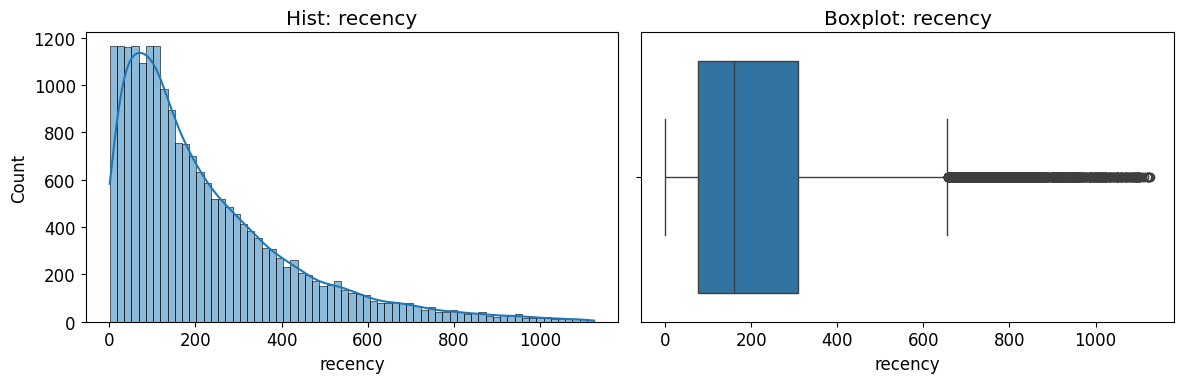

Столбец:  avg_discount 

count    20647.000000
mean         0.101702
std          0.048254
min          0.000000
25%          0.076250
50%          0.100000
75%          0.123000
max          0.250000
Name: avg_discount, dtype: float64
Выбросы:
Количество: 1417
Процент: 6.86
Границы: 0.01 0.19
Первые 5 выбросов выше верхней границы: [0.19333333 0.19333333 0.195      0.19666667 0.2       ]
5 максимальных значений: [0.25 0.25 0.25 0.25 0.25]
Первые 5 выбросов ниже нижней границы: [0.    0.    0.    0.    0.005]
5 минимальных значений: [0. 0. 0. 0. 0.]


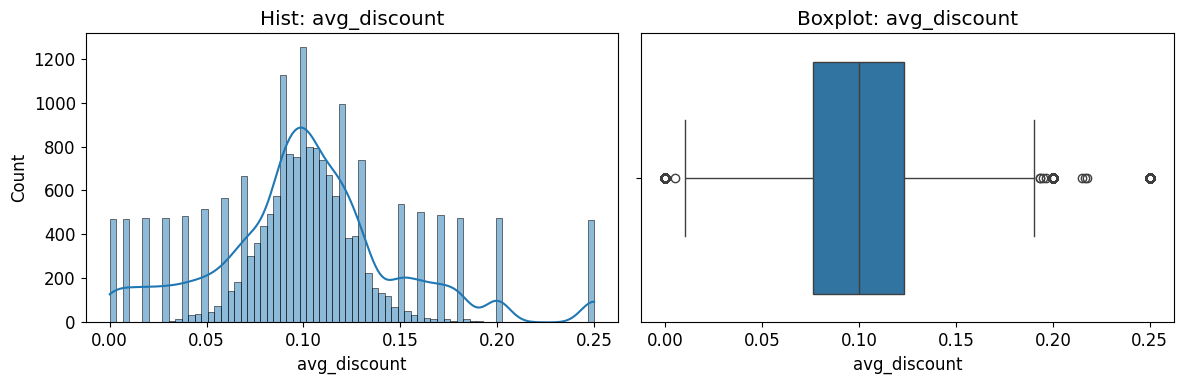

Столбец:  return_rate 

count    20647.000000
mean         0.042977
std          0.156624
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: return_rate, dtype: float64
Выбросы:
Количество: 2633
Процент: 12.75
Границы: 0.0 0.0
Первые 5 выбросов выше верхней границы: [0.02222222 0.02380952 0.02631579 0.02857143 0.02941176]
5 максимальных значений: [1. 1. 1. 1. 1.]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


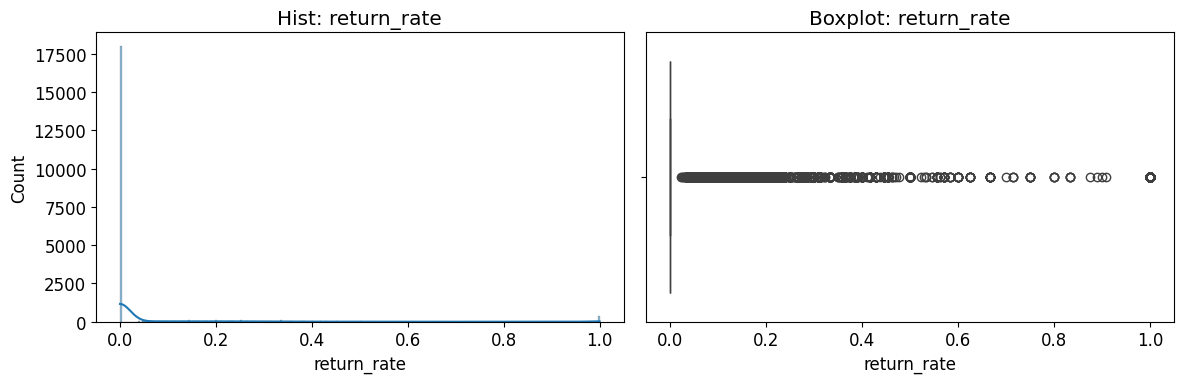



 orders 

Столбец:  item_price 

count    159713.000000
mean        142.180390
std         142.631690
min           9.990000
25%          50.000000
50%          70.000000
75%         199.990005
max        1999.989990
Name: item_price, dtype: float64
Выбросы:
Количество: 2045
Процент: 1.28
Границы: -174.99 424.98
Первые 5 выбросов выше верхней границы: [452.0400085 452.0400085 452.0400085 452.0400085 452.0400085]
5 максимальных значений: [1999.98999 1999.98999 1999.98999 1999.98999 1999.98999]
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


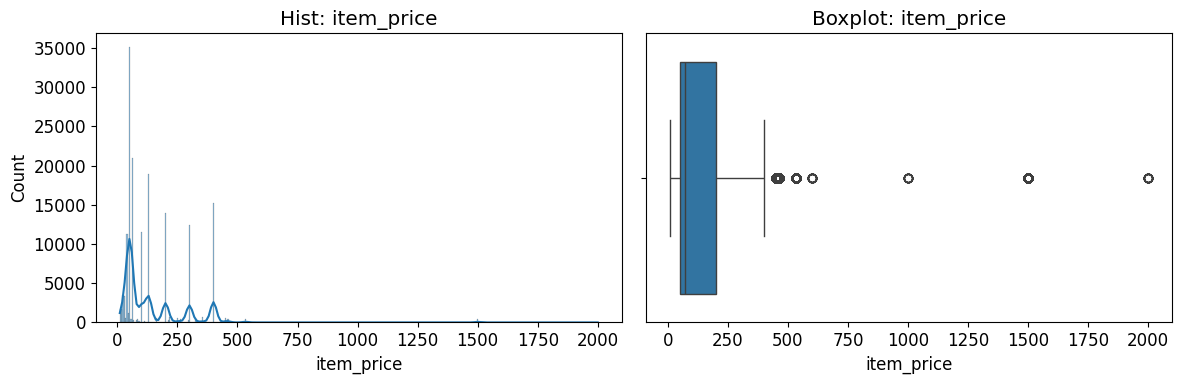

Столбец:  order_hour 

count    159713.000000
mean         11.481401
std           6.925099
min           0.000000
25%           5.000000
50%          11.000000
75%          17.000000
max          23.000000
Name: order_hour, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -13.0 35.0
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


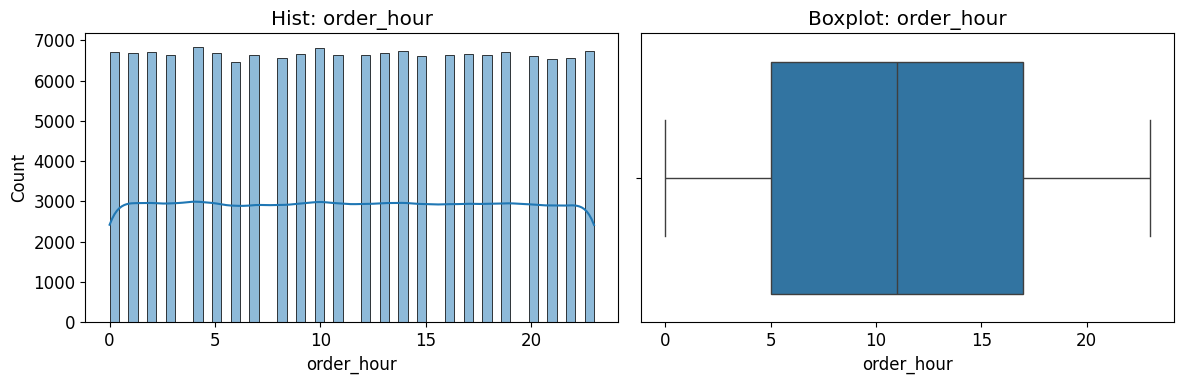

Столбец:  order_weekday 

count    159713.000000
mean          3.008709
std           2.001575
min           0.000000
25%           1.000000
50%           3.000000
75%           5.000000
max           6.000000
Name: order_weekday, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -5.0 11.0
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


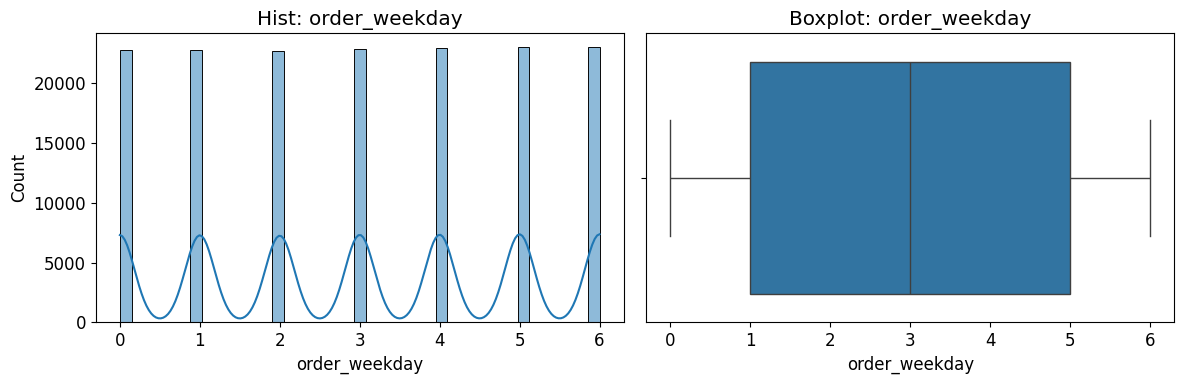

Столбец:  order_month 

count    159713.000000
mean          6.254244
std           3.415452
min           1.000000
25%           3.000000
50%           6.000000
75%           9.000000
max          12.000000
Name: order_month, dtype: float64
Выбросы:
Количество: 0
Процент: 0.0
Границы: -6.0 18.0
Первые 5 выбросов выше верхней границы: []
5 максимальных значений: []
Первые 5 выбросов ниже нижней границы: []
5 минимальных значений: []


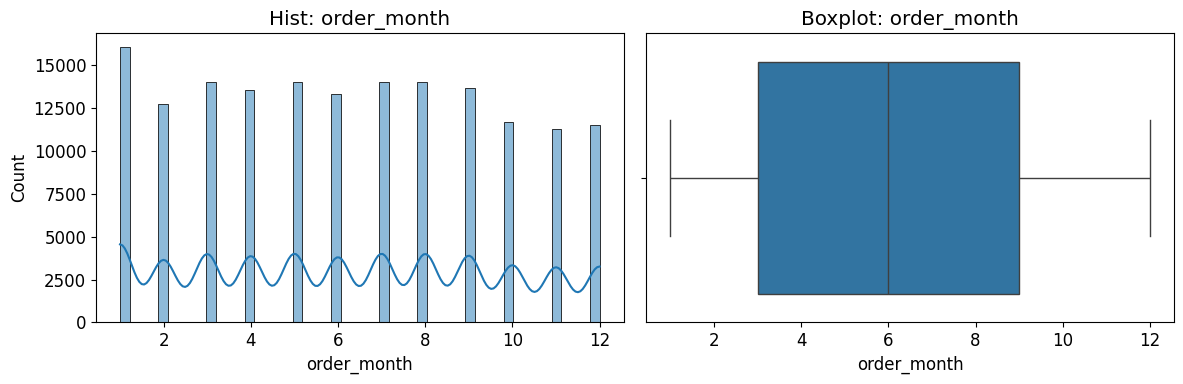

In [14]:
num_cols = ['item_price', 'order_hour', 'order_weekday', 
            'order_month', 'total_sales', 'total_orders', 'recency', 'avg_discount', 'return_rate']

for name, df in datasets.items():
    cols = [col for col in num_cols if col in df.columns]
    if cols:
        print("\n\n", name, "\n")
        for col in cols:
            print("Столбец: ", col, "\n")
            data_review(df, col)


<h3>Проверка на мультиколлиниарность признаков</h3>

In [15]:
def phik_corr_matrix(df, interval_cols=None, drop_cols=None):
    data = df.copy()
    
    if drop_cols:
        data = data.drop(columns=drop_cols, errors='ignore')

    plt.figure(figsize = (8, 6))
    corr = data.phik_matrix(interval_cols=interval_cols)
    display(corr)
    sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f')
    plt.show()
    
    return corr

Корреляции в customers


,customer_lat,customer_lon,total_sales,total_orders,avg_discount,return_rate,recency
customer_lat,1.000000,0.821802,0.000000,0.000000,0.000000,0.000000,0.000000
customer_lon,0.821802,1.000000,0.021499,0.046646,0.000000,0.000000,0.000000
total_sales,0.000000,0.021499,1.000000,0.880510,0.593832,0.367600,0.692487
total_orders,0.000000,0.046646,0.880510,1.000000,0.589426,0.372280,0.697123
avg_discount,0.000000,0.000000,0.593832,0.589426,1.000000,0.223029,0.591160
return_rate,0.000000,0.000000,0.367600,0.372280,0.223029,1.000000,0.301557
recency,0.000000,0.000000,0.692487,0.697123,0.591160,0.301557,1.000000


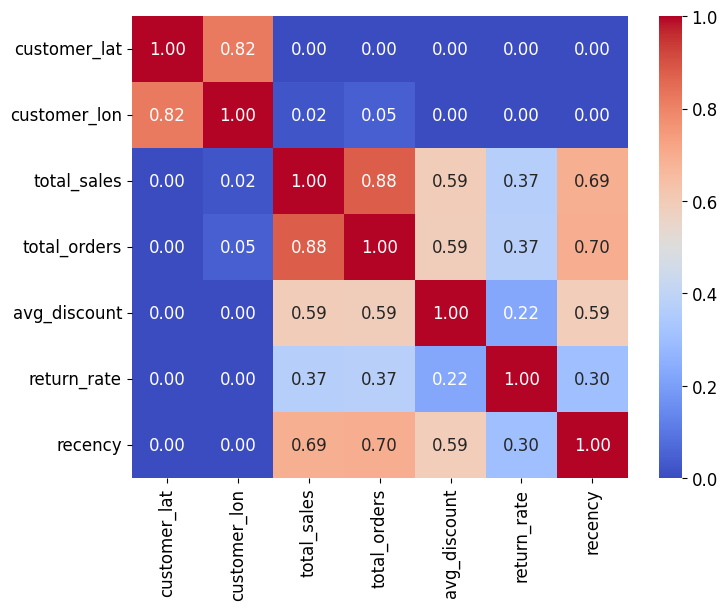


Корреляции в orders


,late_delivery_risk,shipping_mode,category_name,item_price,order_month,order_weekday,order_hour
late_delivery_risk,1.000000,0.653162,0.000000,0.005765,0.002948,0.002303,0.074860
shipping_mode,0.653162,1.000000,0.036811,0.012652,0.040153,0.008057,0.050112
category_name,0.000000,0.036811,1.000000,0.961668,0.508940,0.113089,0.000000
item_price,0.005765,0.012652,0.961668,1.000000,0.272813,0.030561,0.000000
order_month,0.002948,0.040153,0.508940,0.272813,1.000000,0.039651,0.052489
order_weekday,0.002303,0.008057,0.113089,0.030561,0.039651,1.000000,0.003865
order_hour,0.074860,0.050112,0.000000,0.000000,0.052489,0.003865,1.000000


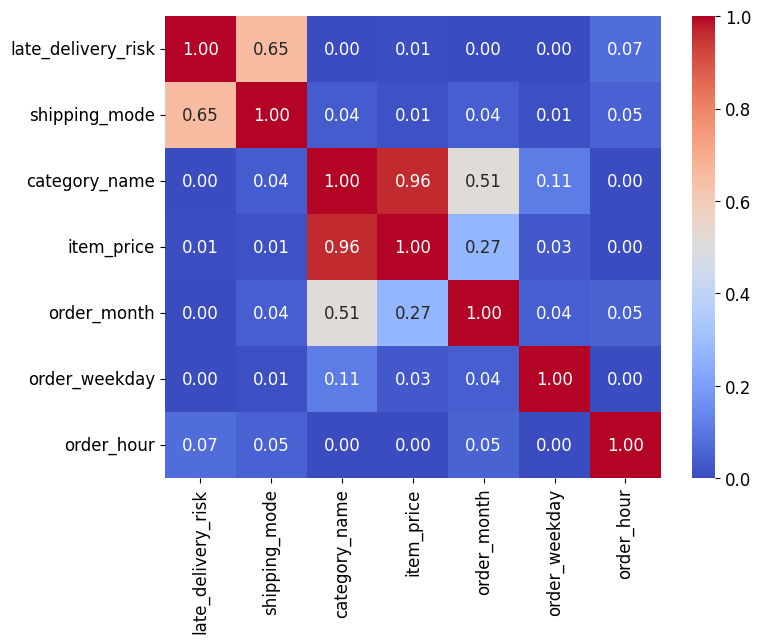

In [16]:
drop_cols = ['customer_id', 'order_id', 'order_date']
interval_cols = ['item_price', 'total_sales', 'total_orders', 'recency', 'avg_discount', 'return_rate', 'customer_lat', 'customer_lon']

for name, df in datasets.items():
    print('Корреляции в', name)
    phik_corr_matrix(df, interval_cols, drop_cols)
    print()

<ul>
    <ul><b>Кореляции в customers</b>
        <li><code>customer_lat</code> и <code>customer_lon</code> cильно коррелируют между собой это связано с клстерами которые образуют точки по широте и долготе</li>
        <li><code>total_sales</code> сильная связь в <code>total_orders</code> чем больше заказов тем больше клиент оставляет денег связь обоснована</li>
        <li><code>avg_discount</code> умеренная связь с <code>total_sales</code>, <code>total_orders</code> и <code>recency</code> связи могут быть вызваны бизнес стратегией компании с целью либо на удержание клиента, либо на привлечения новых проверим это рассмотрев как изменяется <code>avg_discount</code> при изменение <code>total_orders</code></li>
        <li><code>return_rate</code> умеренная связь с <code>total_sales</code>, <code>total_orders</code> и <code>recency</code> есть умеренная связь вероятности возврата с профилем клиента есть обоснование для дальнейшей кластеризации клиентов</li>
        <li><code>recency</code> сильная связь с <code>total_sales</code>, <code>total_orders</code> и умеренная связ с <code>recency</code> количество неактивных дней клиента зависит от его активности, проверим зависимость <code>recency</code> от <code>total_orders</code></li>
    </ul>
    <ul><b>Корреляции в orders</b>
        <li><code>late_delivery_risk</code> и <code>shipping_mode</code> сильная связь типы доставки имеют разный риск задержки, проверим распределение целевой переменной по типам доставки</li>
        <li><code>category_name</code> и <code>item_price</code> сильная связь разные категории товаров имеют разные ценовые диапазоны связь объясняется природой бизнеса, с <code>order_month</code> умеренная связь имеет место сезонность, в разные месяцы популярны разные категории товаров проверим: какие категории заказывают чаще в определённые месяцы</li>
        <li>Признаки времени и дня недели слабо связаня с целевой переменной</li>
    </ul>
</ul>
    Все связи между признаками обоснованы природой данных и имеют обоснование с точки зрения бизнеса
</ul>

Распределение целевой переменной по способам доставки


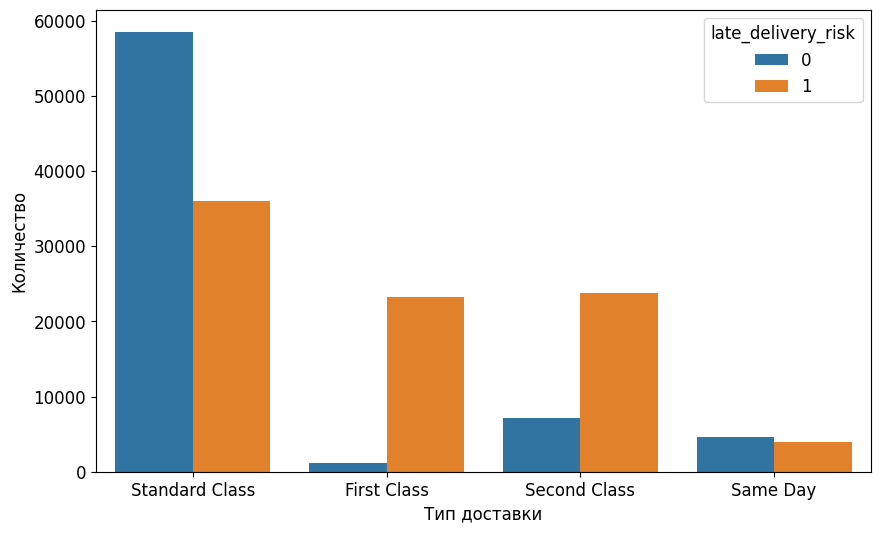

avg_discount при изменении total_orders


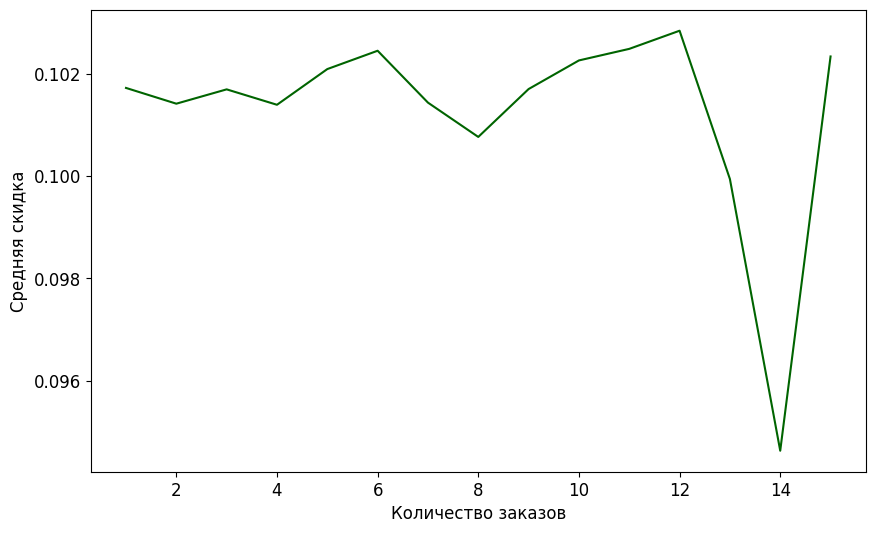

recency при изменении total_orders


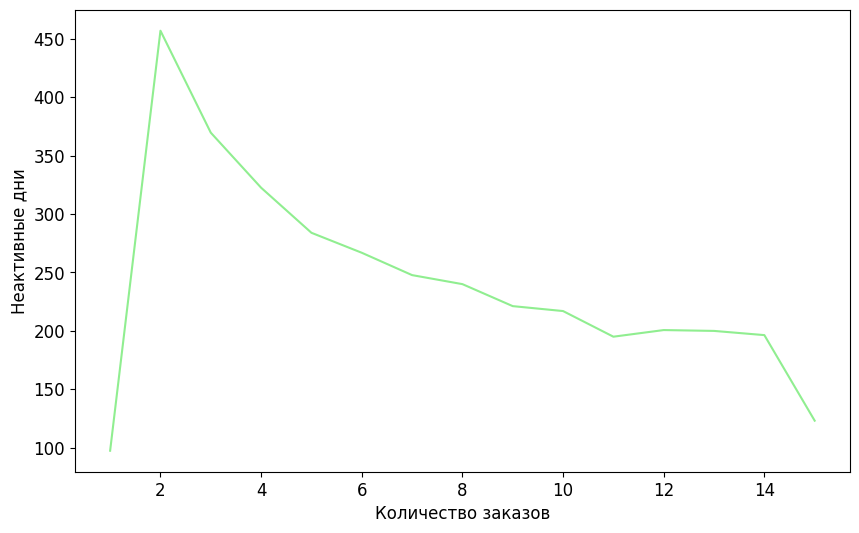

In [17]:
print("Распределение целевой переменной по способам доставки")
sns.countplot(data=orders, x='shipping_mode', hue='late_delivery_risk')
plt.xlabel('Тип доставки')
plt.ylabel('Количество')
plt.show()

print('avg_discount при изменении total_orders')
avg_by_orders = customers.groupby('total_orders')['avg_discount'].mean().reset_index()
plt.plot(avg_by_orders['total_orders'], avg_by_orders['avg_discount'], color='darkgreen')
plt.xlabel('Количество заказов')
plt.ylabel('Средняя скидка')
plt.show()

print('recency при изменении total_orders')
avg_recency = customers.groupby('total_orders')['recency'].mean().reset_index()
plt.plot(avg_recency['total_orders'], avg_recency['recency'], color='lightgreen')
plt.xlabel('Количество заказов')
plt.ylabel('Неактивные дни')
plt.show()

<ul>
    <li>Скидочная политика не зависит явно от количества заказов клиента средняя скидка стабильна, отклонение на отметке 14 вызвано малым числом данных</li>
    <li>Клиенты с <code>total_orders=2</code> имеют аномально высокий <code>recency</code> большая часть клиентов не возвращается после 2-го заказа</li>
    <li>После 3 заказов <code>recency</code> стабильно снижается значит оставшиеся клиенты становятся лояльными</li>
    <li>Необходимо усилить удержание именно на переходе с 1 на 2-3 заказ</li>
</ul>

<h2>Этап 3: Создание выборок (GroupShuffleSplit)</h2>

In [18]:
groups = orders['customer_id']
gss = GroupShuffleSplit(n_splits=1, test_size=0.4, random_state=RANDOM_STATE)
train_idx, temp_idx = next(gss.split(orders, groups=groups))

train = orders.iloc[train_idx]
temp = orders.iloc[temp_idx]

groups_temp = temp['customer_id']
gss = GroupShuffleSplit(n_splits=1, test_size=0.5, random_state=RANDOM_STATE)
val, test = next(gss.split(temp, groups=groups_temp))

val = temp.iloc[val]
test = temp.iloc[test]

print(f"Train: {len(train)} {len(train)/len(orders)*100:.1f}")
print(f"Val:   {len(val)} {len(val)/len(orders)*100:.1f}")
print(f"Test:  {len(test)} {len(test)/len(orders)*100:.1f}")

Train: 95083 60.0
Val:   31350 19.8
Test:  32011 20.2


In [19]:
train_in_val = train['customer_id'].isin(val['customer_id']).sum()
train_in_test = train['customer_id'].isin(test['customer_id']).sum()
val_in_test = val['customer_id'].isin(test['customer_id']).sum()
is_intersections = val_in_test > 0 or train_in_test > 0 or train_in_val > 0
if is_intersections:
    print("Пересечения есть")
else:
    print("Пересечений нет")

Пересечений нет


<h2>Этап 4: Обучение базовой модели</h2>

Объявим пайплайн для обучения логистической регрессии

In [20]:
num_cols = ['item_price', 'order_hour', 'order_weekday', 'order_month']
cat_cols = ['shipping_mode', 'category_name']
preprocessor_logreg = ColumnTransformer(transformers=[('num', StandardScaler(), num_cols),
                                                      ('cat_ohe', OneHotEncoder(handle_unknown='ignore'), ['shipping_mode']),
                                                      ('cat_oe', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['category_name'])])   

Зададим явно тип category для модели CatBoost

In [21]:
for col in cat_cols:
    train[col] = train[col].astype('category')
    val[col] = val[col].astype('category')
    test[col] = test[col].astype('category')
    print(col, 'тип:', train[col].dtype)

shipping_mode тип: category
category_name тип: category


объявим модели и метрики

In [22]:
target = 'late_delivery_risk'

X_train = train[num_cols + cat_cols]
y_train = train[target]

X_val = val[num_cols + cat_cols]
y_val = val[target]
pipeline_logreg = Pipeline(steps=[('preprocessor', preprocessor_logreg),
                                  ('classifier', LogisticRegression(random_state=RANDOM_STATE))])

catboost = CatBoostClassifier(cat_features=cat_cols, depth=5, random_state=RANDOM_STATE)
scoring = {'roc_auc': roc_auc_score,
           'auc_pr': average_precision_score,
           'accuracy': accuracy_score,
           'precision': precision_score,
           'recall': recall_score,
           'f1': f1_score}

Функция запуска

In [23]:
def evaluate_model(model, model_name, X_train, y_train, X_val, y_val, scoring=scoring, fit_params={}):
    start = time.time()
    model.fit(X_train, y_train, **fit_params)
    duration = time.time() - start
    
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)[:, 1]
    
    metrics = {'Model': model_name, 'Duration': round(duration, 2)}
    for metric_name, scorer in scoring.items():
        if metric_name in ('roc_auc', 'auc_pr'):
            metrics[metric_name] = scorer(y_val, y_proba)
        else:
            metrics[metric_name] = scorer(y_val, y_pred)
    
    return model, metrics

In [24]:
pipeline_logreg, metrics_logreg = evaluate_model(pipeline_logreg, 'LogisticRegression', X_train, y_train, X_val, y_val)


catboost, metrics_catboost = evaluate_model(catboost, 'CatBoost', X_train, y_train, X_val, y_val, fit_params={'cat_features': cat_cols,
'early_stopping_rounds': 100, 'verbose': 0})

results_df = pd.DataFrame([metrics_logreg, metrics_catboost])
results_df

,Model,Duration,roc_auc,auc_pr,accuracy,precision,recall,f1
0,LogisticRegression,0.22,0.732464,0.800031,0.703796,0.850550,0.557663,0.673649
1,CatBoost,36.55,0.757603,0.816467,0.721691,0.853691,0.594146,0.700655


<ul>
    <li>CatBoost показал лучший результат по <code>ROC-AUC (0.758)</code> целевая метрика <b>0.75 уже достигнута</b> на базовых настройках</li>
    <li>Обе модели осторожны <code>precision</code> ощутимо выше <code>recall</code>. Модели отдают предпочтение точности предсказаний, но пропускают задержек</li>
    <li>CatBoost лучше по всем метрикам, но требует значительно больше времени на обучение</li>
</ul>

<h2>Этап 5: Кластеризация по географическим признакам</h2>

In [25]:
def centroids_selection(X, low_border, upper_border, preprocess):
    ks = range(low_border, upper_border)  
    wcss = []   
    
    for k in ks:
        pipe = Pipeline(steps=[
            ("prep", preprocess),
            ("kmeans", KMeans(n_clusters=k, random_state=42))
        ])
        pipe.fit(X)
    
        inertia = pipe.named_steps["kmeans"].inertia_
        wcss.append(inertia)  
    
    plt.figure(figsize=(7, 4))
    plt.plot(list(ks), wcss, marker="o")  
    plt.xticks(list(ks))  
    plt.xlabel("K (число кластеров)")
    plt.ylabel("WCSS (inertia_)")
    plt.title("Метод локтя: WCSS по разным K")
    plt.grid(True)
    plt.show()

In [26]:
preprocess_geo = ColumnTransformer(transformers=[('scaler', StandardScaler(), ['customer_lat', 'customer_lon'])])

для защиты от утечки используем информацию толтко о тех клиентах что попали в train после GroupShuffleSplit

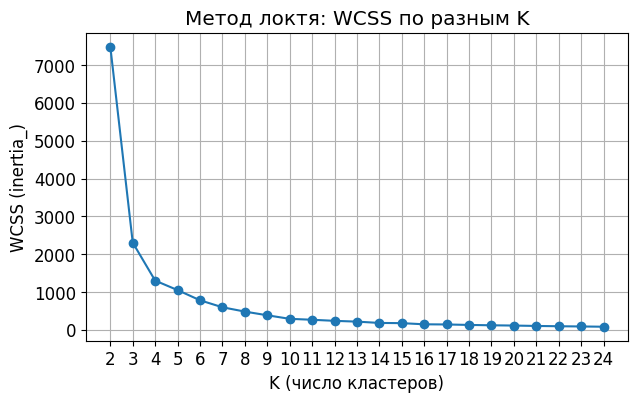

In [27]:
train_customer_ids = train['customer_id'].unique()
customers_train = customers[customers['customer_id'].isin(train_customer_ids)]
centroids_selection(customers_train[['customer_lat', 'customer_lon']], 2, 25, preprocess_geo)

Берем число кластеров равное 6

In [28]:
pipe_geo = Pipeline(steps=[('prep', preprocess_geo), ('kmeans', KMeans(n_clusters=6, random_state=RANDOM_STATE))])

pipe_geo.fit(customers_train[['customer_lat', 'customer_lon']])

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('prep', ...), ('kmeans', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](2,)","['customer_lat','customer_lon']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,2
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dat

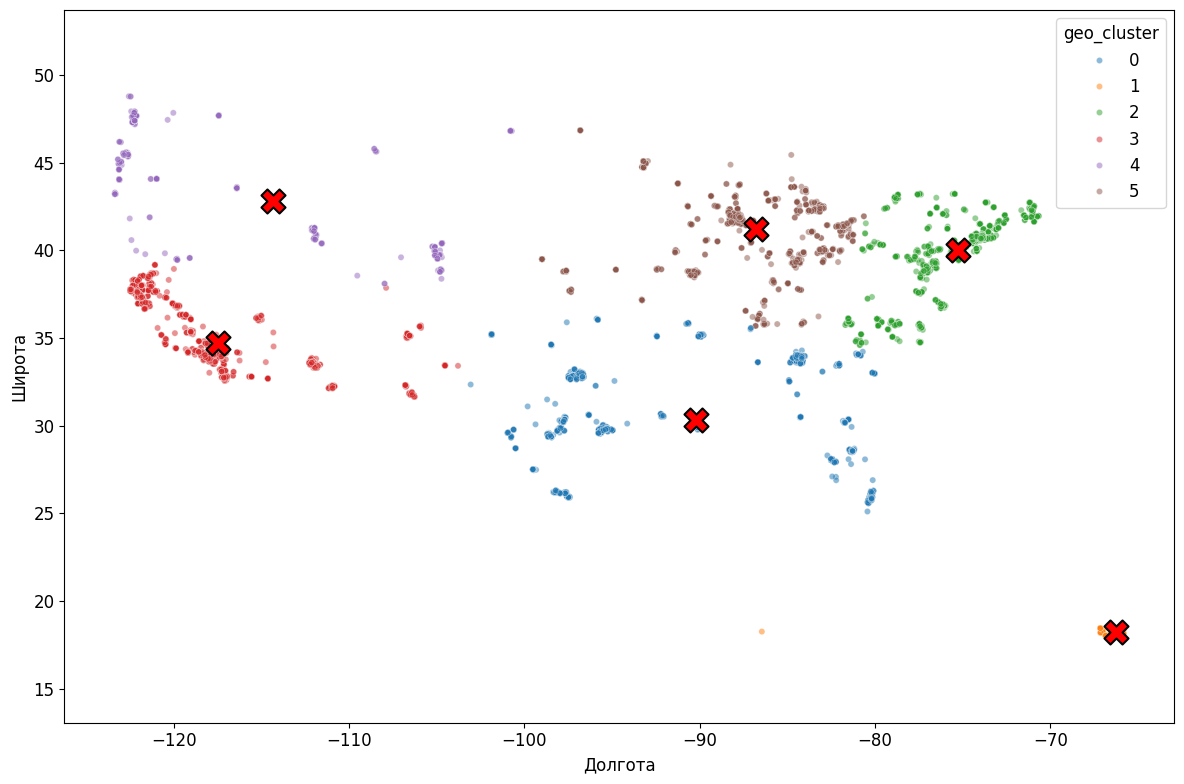

In [29]:
customers_train['geo_cluster'] = pipe_geo.named_steps['kmeans'].labels_
centroids_scaled = pipe_geo.named_steps['kmeans'].cluster_centers_
scaler = pipe_geo.named_steps['prep'].named_transformers_['scaler']
centroids_original = scaler.inverse_transform(centroids_scaled)

plt.figure(figsize=(12, 8))
sns.scatterplot(data=customers_train, x='customer_lon', y='customer_lat', hue='geo_cluster', palette='tab10', alpha=0.5, s=20, legend='full')
plt.scatter(centroids_original[:, 1], centroids_original[:, 0], marker='X', s=300, c='red', edgecolor='black', linewidth=1.5, label='Центроиды')
plt.xlabel('Долгота')
plt.ylabel('Широта')
plt.axis('equal')
plt.tight_layout()
plt.show()

<h2>Этап 6: Кластеризация по профилям клиентов</h2>

In [30]:
cols = ['recency', 'total_orders', 'total_sales', 'return_rate', 'avg_discount']

preprocess_rfm = ColumnTransformer(transformers=[('scaler', StandardScaler(), cols)])

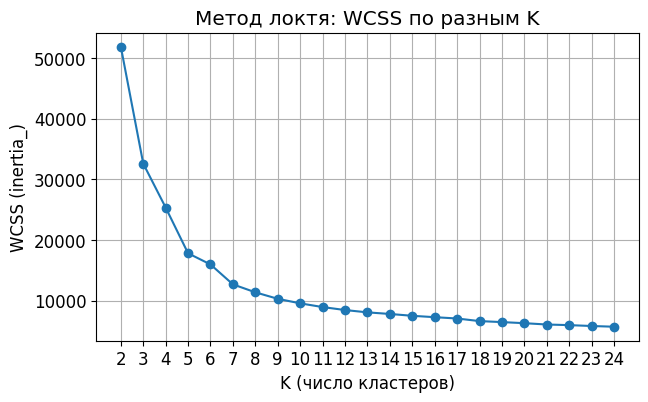

In [31]:
centroids_selection(customers_train[cols], 2, 25, preprocess_rfm)

In [32]:
K = 6

pipe_rfm = Pipeline(steps=[('prep', preprocess_rfm), ('kmeans', KMeans(n_clusters=K, random_state=RANDOM_STATE))])

pipe_rfm.fit(customers_train[cols])
customers_train['rfm_cluster'] = pipe_rfm.named_steps['kmeans'].labels_
customers_train['rfm_cluster'] = pipe_rfm.named_steps['kmeans'].labels_
customers_train[cols + ['rfm_cluster']].groupby('rfm_cluster').mean()

,recency,total_orders,total_sales,return_rate,avg_discount
rfm_cluster,,,,,
0,79.327598,1.203508,409.961223,0.000210,0.052014
1,138.133047,1.103004,323.437555,0.985505,0.103741
2,521.771291,3.024583,1536.170210,0.005248,0.101243
3,76.271584,1.138307,318.460969,0.000174,0.168194
4,236.366872,6.093658,3379.311231,0.020720,0.101608
5,309.410658,4.471787,2340.952313,0.308341,0.101907


<ul>
    <li>Кластер 1 с массовыми возвратами аномально высокий <code>return_rate</code> сегмент риска</li>
    <li>Кластер 2 Утерянные клиенты самый высокий <code>recency</code> клиенты, давно не совершавшие покупок</li>
    <li>Кластер 3 Лояльные клиенты максимум заказов и продаж низкий процент возвратов</li>
    <li>Кластеры 6,7 Новые клиенты</b>: минимальный <code>recency</code> и 1 заказ, но с разным уровнем скидки разная стратегия привлечения</li>
    <li>RFM-кластеризация нашла поведенческие сегменты с разными рисками для бизнес. Подтверждена гипотеза со связью с поведением клиента</li>
</ul>

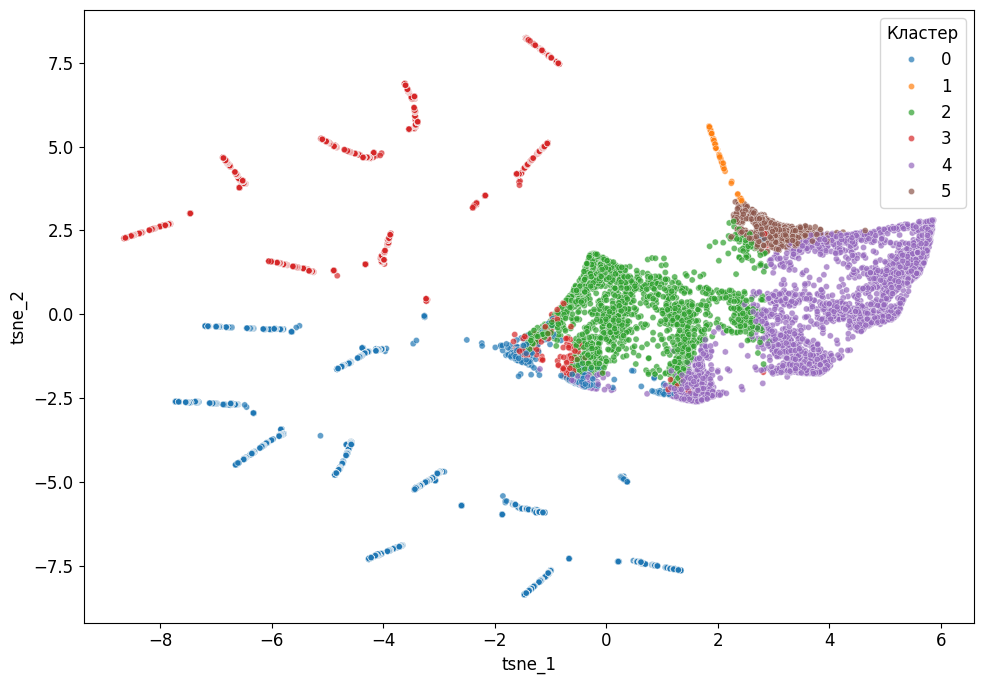

In [33]:
X_scaled = pipe_rfm.named_steps['prep'].transform(customers_train[cols])

color_values = customers_train['rfm_cluster'].values

tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=RANDOM_STATE, init='pca', max_iter=250)
X_tsne = tsne.fit_transform(X_scaled)

tsne_df = pd.DataFrame(X_tsne, columns=['tsne_1', 'tsne_2'])
tsne_df['rfm_cluster'] = color_values

plt.figure(figsize=(10, 7))
sns.scatterplot(data=tsne_df, x='tsne_1', y='tsne_2', hue='rfm_cluster', palette='tab10',s=20, alpha=0.7)
plt.xlabel('tsne_1')
plt.ylabel('tsne_2')
plt.legend(title='Кластер')
plt.tight_layout()
plt.show()

<h2>Этап 7: Обучение модели на новых признаках</h2>

Пременим препроцессоры к выборкам для val и test 

In [34]:
val_customer_ids = val['customer_id'].unique()
test_customer_ids = test['customer_id'].unique()

customers_val = customers[customers['customer_id'].isin(val_customer_ids)].copy()
customers_test = customers[customers['customer_id'].isin(test_customer_ids)].copy()

In [35]:
customers_val['geo_cluster'] = pipe_geo.predict(customers_val[['customer_lat', 'customer_lon']])
customers_val['rfm_cluster'] = pipe_rfm.predict(customers_val[cols])

customers_test['geo_cluster'] = pipe_geo.predict(customers_test[['customer_lat', 'customer_lon']])
customers_test['rfm_cluster'] = pipe_rfm.predict(customers_test[cols])

In [36]:
cluster_cols = ['customer_id', 'geo_cluster', 'rfm_cluster']

train = train.merge(customers_train[cluster_cols], on='customer_id', how='left')
val = val.merge(customers_val[cluster_cols], on='customer_id', how='left')
test = test.merge(customers_test[cluster_cols], on='customer_id', how='left')

In [37]:
for name, df in [('train', train), ('val', val), ('test', test)]:
    print(f"{name}: пропусков: {df[['geo_cluster', 'rfm_cluster']].isna().sum().sum()} строк: {len(df)}")

train: пропусков: 0 строк: 95083
val: пропусков: 0 строк: 31350
test: пропусков: 0 строк: 32011


новых пропусков не появилось количество строк совпадает с исходным благодаря левостороннему присоединению 

In [38]:
cat_cols = cat_cols + ['geo_cluster', 'rfm_cluster']

X_train = train[num_cols + cat_cols]
y_train = train[target]

X_val = val[num_cols + cat_cols]
y_val = val[target]

In [41]:
catboost = CatBoostClassifier(cat_features=cat_cols, depth=5, random_state=RANDOM_STATE)
pipeline_logreg = Pipeline(steps=[('preprocessor', preprocessor_logreg),
                                  ('classifier', LogisticRegression(random_state=RANDOM_STATE))])

preprocessor_logreg = ColumnTransformer(transformers=[('num', StandardScaler(), num_cols),
                                                      ('cat_ohe', OneHotEncoder(handle_unknown='ignore'), ['shipping_mode', 'geo_cluster', 'rfm_cluster']),
                                                      ('cat_oe', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['category_name'])])
pipeline_logreg, metrics_logreg = evaluate_model(pipeline_logreg, 'LogisticRegression', X_train, y_train, X_val, y_val)
catboost, metrics_catboost = evaluate_model(catboost, 'CatBoost', X_train, y_train, X_val, y_val, fit_params={'cat_features': cat_cols,
'early_stopping_rounds': 100, 'verbose': 0})

results_df = pd.DataFrame([metrics_logreg, metrics_catboost])
results_df

,Model,Duration,roc_auc,auc_pr,accuracy,precision,recall,f1
0,LogisticRegression,0.24,0.738381,0.807531,0.705805,0.850392,0.562260,0.676941
1,CatBoost,41.02,0.772636,0.836216,0.721882,0.854832,0.593448,0.700553


<ul>
    <li>CatBoost: ROC-AUC вырос с 0.758 до 0.773. Гипотеза о полезности профилирования клиентов подтвердилась</li>
    <li>LogisticRegression: метрики слабо изменились ROC-AUC с 0.732 до 0.738 линейная модель не смогла извлечь значимую пользу из кластерных признаков</li>
    <li>CatBoost лучше улавливает нелинейные зависимости в данных о сегментах клиентов, поэтому она выигрывает при добавление кластеров</li>
</ul>

<h2>Этап 8: Тестирование лучшей модели</h2>

In [ ]:
X_test = test[num_cols + cat_cols]
y_test = test[target]
y_pred = catboost.predict(X_test)
y_proba = catboost.predict_proba(X_test)[:, 1]
    
metrics = {'Model': 'catboost'}
for metric_name, scorer in scoring.items():
    if metric_name in ('roc_auc', 'auc_pr'):
        metrics[metric_name] = scorer(y_test, y_proba)
    else:
        metrics[metric_name] = scorer(y_test, y_pred)


pd.DataFrame([metrics])
display(metrics)
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
cm_df = pd.DataFrame(cm, index=['Фактическое 0', 'Фактическое 1'],
                         columns=['Прогноз 0', 'Прогноз 1'])
print(cm_df)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_df, annot=True)
plt.ylabel('Фактическое')
plt.xlabel('Прогноз')
plt.show()

In [ ]:
def create_SHAP(model, df, model_name):
    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(df)

    plt.figure(figsize=(6, 4))
    shap.summary_plot(shap_values, df, show=False)
    plt.title(f"SHAP Summary Plot: {model_name}")
    plt.tight_layout()
    plt.show()

    return shap_values

In [ ]:
shap_values_xgb = create_SHAP(catboost, X_test, "CatBoost")

<h4>Результаты на тестовой выборке</h4>
<ul>
    <li>ROC-AUC на тесте 0.761 близко к значению на валидации 0.773 </li>
    <li>Совпадение метрик подтверждает, что модель обобщает закономерности переобучения нет</li>
</ul>

<ul>
    <li>shipping_mode самый влиятельный признак, подтверждает вывод из EDA о сильной связи типа доставки с риском задержки</li>
    <li>order_hour и rfm_cluster 2 и 3 места по значимости, что подтверждает пользу RFM-сегментации</li>
    <li>geo_cluster на 4 месте, менее значим, чем поведенческий кластер, но важнее большинства признаков</li>
    <li>category_name и <b>item_price наименее значимы для модели, несмотря на сильную корреляцию</li>
    <li>оба созданных кластерных признака оказались значимее большинства исходных признаков, гипотеза о необходимости кластеризации подтверждена важностью признаков</li>
</ul>

<h2>Этап 9: Выводы и рекомендации для бизнеса</h2>

<h4>Результаты моделирования</h4>
<ul>
    <li>Итоговая модель CatBoost с географическими и поведенческими кластерами ROC-AUC 0.761 на тесте, целевой порог 0.75 пройден</li>
    <li>Добавление кластеров подняло качество с 0.758 до 0.761–0.773 в зависимости от выборки, подтвердилась польза о разбиение клинтов на кластеры</li> 
    <li>Текущая модель настроена на precision в ущерб recall: она редко ошибается с задержкой, но пропускает 41% реальных задержек, стоит сдвинуть в сторону recall, если цена пропущенной задержки выше цены ложного срабатывания.</li>
</ul>

<h4>Проверка гипотез</h4>
<ul>
    <li>RFM-кластеризация выделила разные сегменты по <code>return_rate</code></li>
    <li>Анализ <code>recency</code> в зависимости от <code>total_orders</code> показал: у клиентов с 1–2 покупками значительная часть, не доходя до статуса лояльных. Риск с удержанием клиентов</li>
    <li>Распределение целевой переменной по <code>shipping_mode</code> показало, что характерны в основном для ускоренных способах доставки. Более быстрые и дорогие тарифы оказались менее надёжными, из-за временных окон и следовательно меньшего запаса времени</li>
    <li>Поведенческий кластер вошёл в топ 3 самых влиятельных признаков модели. Географический кластер также оказался значимее большинства признаков заказа.</li>
</ul>

<h4>Эффективность сегментации</h4>
<ul>
    <li>Поведенческая кластеризация оказалась информативнее географической <code>rfm_cluster</code> 3 место в рейтинге <code>geo_cluster</code> 4 место </li>
    <li>Способ доставки и время заказа влияют на логистический процесс, а поведение клиента отражает шаблоны, с которыми связаны задержки</li>
</ul>

<h4>Бизнес-рекомендации</h4>
<ul>
    <li>Внедрить модель на этапе оформления заказа - это позволит заранее предупреждать клиента о повышенном риске</li>
    <li>Пересмотреть критерии для ускоренных тарифов доставки, т.к. именно они несут наибольший риск задержки</li>
    <li>Сосредоточиться на удержании новых клиентов, так как именно в этой точке наибольший отток</li>
    <li>Использовать модель как вспомогательный инструмент: заказы с высоким предсказанным риском можно направлять на более надёжный путь</li>
</ul>

<div style="border:solid Chocolate 2px; padding: 40px">

**Общий вывод по проекту**
    
Спасибо за твой проект! Ты достаточно внимательно подходишь к решению, вникаешь в контекст данных, следуешь подсказкам и заданиям из описания проекта.
    
**Отмечу положительные моменты проекта🚀**
    
* Хорошее оформление, есть комментарии, аргументация решений, выводы.
* Прозрачный код без избыточности.
*  Хорошая схема проекта
* Достигнуты необходимые показатели качества
    
**На что стоит обратить внимание🤔**
    
* Важно добавить пояснения к обучению моделей и к графикам в проекте. 
* Рекомендую также подобрать гиперпараметры к лучшей модели.
* Это и остальные замечания я также написал по ходу проекта.
    
**Желаю удачи и жду твой проект на повторное ревью!**😉
    
    
</div>
      
        